In [ ]:
import os
print(os.getcwd())


In [ ]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append('..')

import utilities.functions as functions
import utilities.descritiva as descritiva

from utilities.functions import (
    load_data,
    check_key_uniqueness,
    merge_df,
    load_orders,
    process_orders_pandas
)
from utilities.descritiva import (
    plot_indicadores_mes_plataforma,
    gerar_stats,
    pedidos_group,
    criacao_ordens

)

In [ ]:
from pathlib import Path
BASE_PATH = Path("/Users/maceli/ifood_cs/dados") 
df = pd.read_parquet(BASE_PATH / "silver" / "df_p_2.parquet")#.drop([ "delivery_address_district", "delivery_address_country",'customer_name','active','created_at','delivery_address_external_id'], axis=1)
df.head()

In [26]:
df["order_created_at"] = pd.to_datetime(df["order_created_at"], utc=True)
df['unique_order_hash'] = pd.util.hash_pandas_object(
        df[['customer_id', 'order_created_at','order_id']],
        index=False
    )
df = df.drop(columns=['order_id'], errors='ignore')
df["order_created_month"] = df["order_created_at"].dt.month
id_both_monht=df[df['order_created_month']==12]['customer_id'].unique()
df = df[df['customer_id'].isin(id_both_monht)].reset_index(drop=True)
df["day_month_year"] = df["order_created_at"].dt.strftime("%d-%m-%Y")
df["weekday"] = df["order_created_at"].dt.day_name()
df["hour"] = df["order_created_at"].dt.hour

df["day"] = df["order_created_at"].dt.day


In [27]:
df_stats_mes = (
        df.groupby(['order_created_month','is_target'])
          .agg(
              total_clientes=('customer_id', 'nunique')))

df_stats_mes  

total_clientes
order_created_month is_target                
1                   control             29978
                    target              38705
12                  control             29978
                    target              38705

Criando dias da semana, dia, hora

In [28]:
summary_mes=gerar_stats(df,['origin_platform'])
summary_mes

,order_created_month,origin_platform,total_clientes,total_pedidos,total_ordem,perc_clientes,perc_pedidos,perc_amount
0,1,IOS,30713,115179,6085496.98,41.52,45.19,49.77
1,1,ANDROID,30431,99537,4298068.58,41.14,39.05,35.15
2,1,DESKTOP,12131,38237,1767403.03,16.40,15.00,14.45
3,1,WINDOWS_PHONE,696,1941,76507.94,0.94,0.76,0.63
4,12,IOS,30124,67879,3551960.22,42.18,44.52,48.91
5,12,ANDROID,29710,60824,2611801.61,41.60,39.90,35.96
6,12,DESKTOP,10949,22552,1051531.40,15.33,14.79,14.48
7,12,WINDOWS_PHONE,640,1198,47436.77,0.90,0.79,0.65


% de clientes com mais de um pedido - no mes %valor e % amount

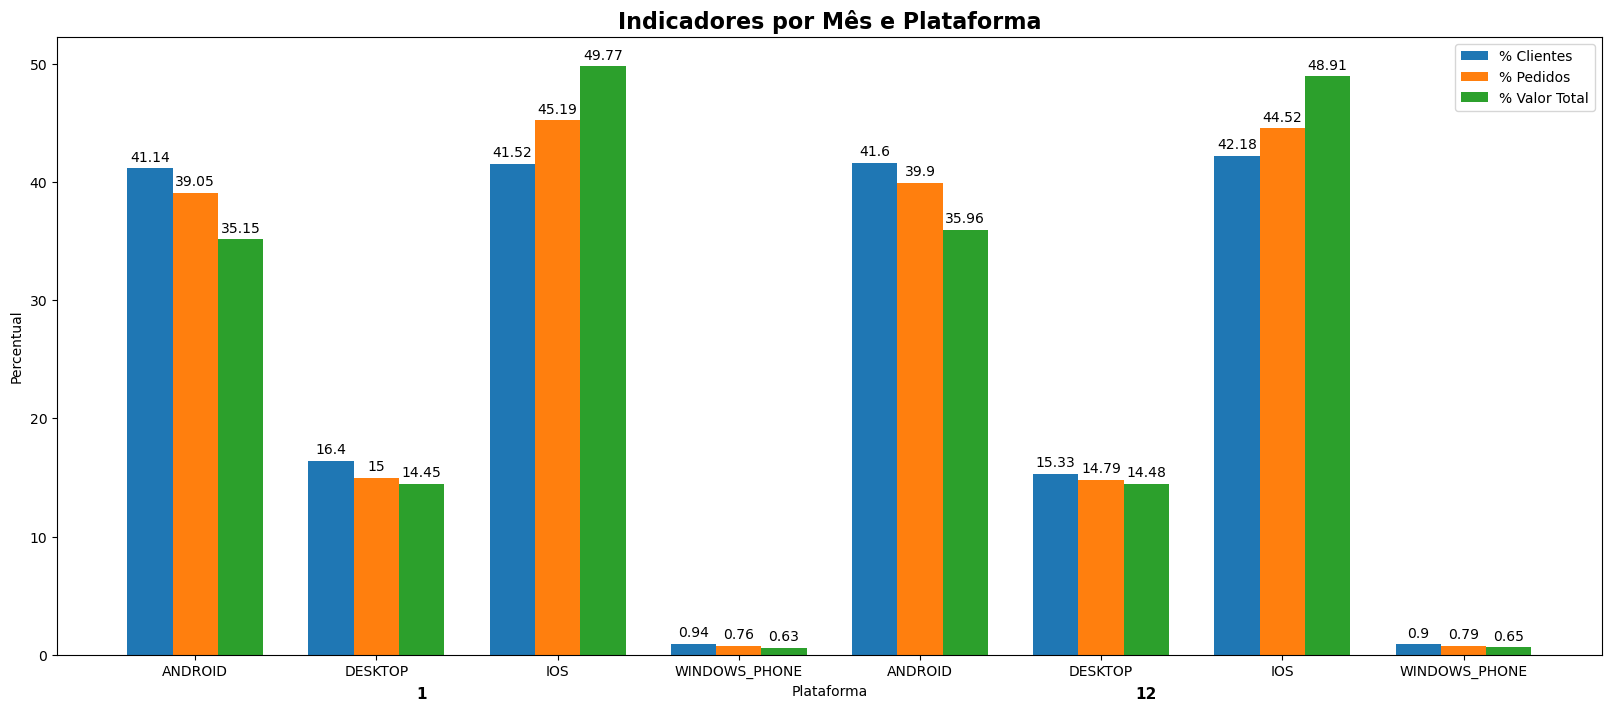

In [29]:
plot_indicadores_mes_plataforma(summary_mes)

In [30]:
pedidos_group(df)

,order_created_month,categoria_pedidos,total_clientes,total_pedidos,total_amount,avg_amount_por_cliente,perc_clientes,perc_pedidos,perc_amount
0,1,1_pedido,24056,24056,1140546.74,47.412152,35.02,9.44,9.33
1,1,2+_pedidos,44627,230838,11086929.79,248.435472,64.98,90.56,90.67
2,12,1_pedido,37161,37161,1785259.63,48.041216,54.11,24.38,24.58
3,12,2+_pedidos,31522,115292,5477470.37,173.766587,45.89,75.62,75.42


In [31]:
df_1000 = df.head(1000)
df_1000, dias_0=criacao_ordens(df_1000)
print(dias_0)
df_1000.head()

4.397058823529412


,customer_id,is_target,active,created_at,delivery_address_state,merchant_id,order_created_at,order_total_amount,origin_platform,unique_order_hash,...,hour,day,rank_month,days_between_orders,days_since_first_order_month,amount_diff_from_previous,amount_pct_change_from_previous,days_until_next_order,is_last_order_month,%desconto
62,002ca070253de5dd983f577e0156dae30cfe981198bce5...,target,True,2018-02-14T22:00:42.221Z,PR,e38f9c3442924c2bcbdc861b58347168ae5ef0e2e0c9e9...,2018-12-08 23:53:09+00:00,69.60,ANDROID,7928551721740928477,...,23,8,1,-9999.0,-999.0,-999.00,0.000000,0.0,False,0.000
63,002ca070253de5dd983f577e0156dae30cfe981198bce5...,target,True,2018-02-14T22:00:42.221Z,PR,f6e7677804606fbf174eab18c1c4952b179eab53842d08...,2018-12-08 23:57:40+00:00,41.64,ANDROID,18382103497042395048,...,23,8,2,0.0,0.0,-27.96,-40.172414,0.0,False,12.492
65,002ca070253de5dd983f577e0156dae30cfe981198bce5...,target,True,2018-02-14T22:00:42.221Z,PR,a214cbc02505dd8299e857d286e9f9a9eb736c15e619a5...,2018-12-09 23:17:15+00:00,64.80,ANDROID,7758816713724899850,...,23,9,3,0.0,0.0,23.16,55.619597,3.0,False,0.000
61,002ca070253de5dd983f577e0156dae30cfe981198bce5...,target,True,2018-02-14T22:00:42.221Z,SP,e2022625ae0915dce1fd6e71b9a3bd552db3687a26413b...,2018-12-13 16:52:20+00:00,17.00,DESKTOP,5315003407026529726,...,16,13,4,3.0,4.0,-47.80,-73.765432,7.0,False,0.000
64,002ca070253de5dd983f577e0156dae30cfe981198bce5...,target,True,2018-02-14T22:00:42.221Z,SP,f7f59e377c330aab696812caa75ec0c512d0ae35fc1186...,2018-12-21 15:40:19+00:00,41.90,DESKTOP,17769712276185939896,...,15,21,5,7.0,12.0,24.90,146.470588,4.0,False,0.000


In [32]:
summary_mes = gerar_stats(
    df_1000[df_1000['rank_month'] == 2],
    ['days_until_next_order']
)

summary_mes.head()

,order_created_month,days_until_next_order,total_clientes,total_pedidos,total_ordem,perc_clientes,perc_pedidos,perc_amount
0,1,0.0,18,18,807.99,24.32,24.32,23.21
1,1,1.0,14,14,785.15,18.92,18.92,22.55
2,1,-999.0,9,9,415.16,12.16,12.16,11.92
3,1,5.0,6,6,287.15,8.11,8.11,8.25
4,1,2.0,5,5,198.90,6.76,6.76,5.71


In [33]:
df_1000.columns


Index(['customer_id', 'is_target', 'active', 'created_at',
       'delivery_address_state', 'merchant_id', 'order_created_at',
       'order_total_amount', 'origin_platform', 'unique_order_hash',
       'order_created_month', 'day_month_year', 'weekday', 'hour', 'day',
       'rank_month', 'days_between_orders', 'days_since_first_order_month',
       'amount_diff_from_previous', 'amount_pct_change_from_previous',
       'days_until_next_order', 'is_last_order_month', '%desconto'],
      dtype='object')

In [38]:
df_ = df_1000[
    [
        'customer_id',
        'order_created_at',
        'order_created_month',
        'is_target',
        'rank_month',
        'order_total_amount',
        'days_between_orders',
        'days_since_first_order_month',
        'unique_order_hash'
    ]
].copy()  # evita SettingWithCopyWarning

df_['converteu'] = False
df_['desconto'] = 0

#df_ = df_.loc[
    #df_['customer_id'] == '002ca070253de5dd983f577e0156dae30cfe981198bce5c7815755748343594c'
#]

df = df_.reset_index(drop=True)

df



,customer_id,order_created_at,order_created_month,is_target,rank_month,order_total_amount,days_between_orders,days_since_first_order_month,unique_order_hash,converteu,desconto
0,002ca070253de5dd983f577e0156dae30cfe981198bce5...,2018-12-08 23:53:09+00:00,12,target,1,69.60,-9999.0,-999.0,7928551721740928477,False,0
1,002ca070253de5dd983f577e0156dae30cfe981198bce5...,2018-12-08 23:57:40+00:00,12,target,2,41.64,0.0,0.0,18382103497042395048,False,0
2,002ca070253de5dd983f577e0156dae30cfe981198bce5...,2018-12-09 23:17:15+00:00,12,target,3,64.80,0.0,0.0,7758816713724899850,False,0
3,002ca070253de5dd983f577e0156dae30cfe981198bce5...,2018-12-13 16:52:20+00:00,12,target,4,17.00,3.0,4.0,5315003407026529726,False,0
4,002ca070253de5dd983f577e0156dae30cfe981198bce5...,2018-12-21 15:40:19+00:00,12,target,5,41.90,7.0,12.0,17769712276185939896,False,0
...,...,...,...,...,...,...,...,...,...,...,...
995,fd6e0598d32b8bfe4d59bf6cdb0997219193e830b3b375...,2019-01-13 22:12:25+00:00,1,target,3,102.00,2.0,4.0,6883508760988405649,False,0
996,fd6e0598d32b8bfe4d59bf6cdb0997219193e830b3b375...,2019-01-21 22:18:47+00:00,1,target,4,63.00,8.0,12.0,780928629719076819,False,0
997,fd6e0598d32b8bfe4d59bf6cdb0997219193e830b3b375...,2019-01-22 22:06:22+00:00,1,target,5,29.50,0.0,13.0,10143040661460681054,False,0
998,fd6e0598d32b8bfe4d59bf6cdb0997219193e830b3b375...,2019-01-24 21:14:26+00:00,1,target,6,42.00,1.0,15.0,10389905771670090583,False,0


In [ ]:
df['customer_id'].nunique()

81

In [50]:
df['converteu'] = (
    (df['order_created_month'] == 1) &
    (df['rank_month'] == 2) &
    (df['days_between_orders'] < window_days)
)
df

,customer_id,order_created_at,order_created_month,is_target,rank_month,order_total_amount,days_between_orders,days_since_first_order_month,unique_order_hash,converteu,desconto,valor_desconto,valor_final
0,002ca070253de5dd983f577e0156dae30cfe981198bce5...,2018-12-08 23:53:09+00:00,12,target,1,69.60,-9999.0,-999.0,7928551721740928477,False,0,0.0,69.60
1,002ca070253de5dd983f577e0156dae30cfe981198bce5...,2018-12-08 23:57:40+00:00,12,target,2,41.64,0.0,0.0,18382103497042395048,False,0,0.0,41.64
2,002ca070253de5dd983f577e0156dae30cfe981198bce5...,2018-12-09 23:17:15+00:00,12,target,3,64.80,0.0,0.0,7758816713724899850,False,0,0.0,64.80
3,002ca070253de5dd983f577e0156dae30cfe981198bce5...,2018-12-13 16:52:20+00:00,12,target,4,17.00,3.0,4.0,5315003407026529726,False,0,0.0,17.00
4,002ca070253de5dd983f577e0156dae30cfe981198bce5...,2018-12-21 15:40:19+00:00,12,target,5,41.90,7.0,12.0,17769712276185939896,False,0,0.0,41.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,fd6e0598d32b8bfe4d59bf6cdb0997219193e830b3b375...,2019-01-13 22:12:25+00:00,1,target,3,102.00,2.0,4.0,6883508760988405649,False,0,0.0,102.00
996,fd6e0598d32b8bfe4d59bf6cdb0997219193e830b3b375...,2019-01-21 22:18:47+00:00,1,target,4,63.00,8.0,12.0,780928629719076819,False,0,0.0,63.00
997,fd6e0598d32b8bfe4d59bf6cdb0997219193e830b3b375...,2019-01-22 22:06:22+00:00,1,target,5,29.50,0.0,13.0,10143040661460681054,False,0,0.0,29.50
998,fd6e0598d32b8bfe4d59bf6cdb0997219193e830b3b375...,2019-01-24 21:14:26+00:00,1,target,6,42.00,1.0,15.0,10389905771670090583,False,0,0.0,42.00


In [57]:
df[df['is_target'] == True]


,customer_id,order_created_at,order_created_month,is_target,rank_month,order_total_amount,days_between_orders,days_since_first_order_month,unique_order_hash,converteu,desconto,valor_desconto,valor_final


In [60]:
import numpy as np

window_days = 5
desconto_p = 0.10  # 10%

# clientes com primeira compra (rank 1)
df_d = df[df['rank_month'].isin([1])][['customer_id', 'is_target']].drop_duplicates()

# flag de conversão: segunda compra no mês 1 dentro da janela
df['converteu'] = (
    (df['order_created_month'] == 1) &
    (df['rank_month'] == 2) &
    (df['days_between_orders'] < window_days)
)

df['valor_desconto'] = np.where(
    (df['is_target'] == 'target'),
    df['order_total_amount'] * desconto_p,
    0
)


# ❌ aqui estava o erro: você usou 'desconto', mas criou 'valor_desconto'
df['valor_final'] = df['order_total_amount'] - df['valor_desconto']

# só segundas compras que converteram
df_conv = df[(df['rank_month'] == 2) & (df['converteu'] == True)]

# junta base de 1ª compra com info da 2ª compra (se tiver)
a = df_d[['customer_id', 'is_target']].merge(
    df_conv[['customer_id', 'converteu',
             'order_total_amount', 'valor_desconto']],
    on='customer_id',
    how='left'  # mantém todo mundo da coorte de primeira compra
)
a['converteu'] = a['converteu'].fillna(False)
a=a.fillna(0)
# agora SIM, salva o resultado do groupby:
resumo = a.groupby('is_target', as_index=False).agg(
    total_clientes=('customer_id', 'nunique'),
    clientes_convertidos=('converteu', 'sum'),
    #total_ordens=('unique_order_hash', 'count'),
    total_amount=('order_total_amount', 'sum'),
    total_desconto=('valor_desconto', 'sum'),
    #avg_amount=('order_total_amount', 'mean')
).assign(
            taxa_conversao=lambda x: (x['clientes_convertidos'] / x['total_clientes'] * 100).round(2),
            total_amount_liquido=lambda x: x['total_amount'] - x['total_desconto'],
           # custo_medio_desconto=lambda x: (x['total_desconto'] / x['clientes_convertidos']).round(2) if x['clientes_convertidos'] > 0 else 0,
            window_dias=window_days
        ).reset_index()

resumo


/var/folders/s5/dkrzm08d6wl79n0by4mcn72m0000gn/T/ipykernel_26467/3891607796.py:36: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  a['converteu'] = a['converteu'].fillna(False)


,index,is_target,total_clientes,clientes_convertidos,total_amount,total_desconto,taxa_conversao,total_amount_liquido,window_dias
0,0,control,39,23,1169.41,0.000,58.97,1169.410,5
1,1,target,42,31,1313.53,131.353,73.81,1182.177,5


In [ ]:
window_days = 2

clientes_convertidos = (
    df[df['rank_month'].isin([1, 2])]
    .assign(
        converteu=lambda x: x['customer_id'].isin(
            df.loc[
                (df['order_created_month'] == 1)# &
                #(df['rank_month'] == 2) #&
                #(df['days_between_orders'] < 5)
                ,
                'customer_id'
            ]
        )
    )
)

clientes_convertidos



In [ ]:
def calcular_summary_com_desconto(df, percentual_desconto=0.3, window_days=2):
    summary_completo = (
        df.query('order_created_month == 1 and rank_month == 1')
        .drop_duplicates(['customer_id', 'order_created_month'])
        .assign(
            converteu=lambda x: x['customer_id'].isin(
                df.query(f'order_created_month == 1 and rank_month == 2 and days_between_orders < {window_days}')
                ['customer_id']
                .unique()
            ),
            valor_desconto=lambda x: np.where(
                (x['converteu']) & (x['is_target'] == 'target'),
                x['order_total_amount'] * percentual_desconto,
                0.0
            )
        )
        .groupby('is_target')
        .agg(
            total_clientes=('customer_id', 'nunique'),
            clientes_convertidos=('converteu', 'sum'),
            total_ordens=('unique_order_hash', 'count'),
            total_amount=('order_total_amount', 'sum'),
            total_desconto=('valor_desconto', 'sum'),
            avg_amount=('order_total_amount', 'mean')
        )
        .assign(
            taxa_conversao=lambda x: (x['clientes_convertidos'] / x['total_clientes'] * 100).round(2),
            total_amount_liquido=lambda x: x['total_amount'] - x['total_desconto'],
            custo_medio_desconto=lambda x: (x['total_desconto'] / x['clientes_convertidos']).round(2) if x['clientes_convertidos'] > 0 else 0,
            window_dias=window_days
        )
        .reset_index()
    )
    return summary_completo

# USO COM DIFERENTES JANELAS
calcular_summary_com_desconto(df_1000)

In [ ]:
summary_completo

In [ ]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

def calcular_poder_estatistico_ab(n_control, n_target, p_base, alpha=0.05, efeito_observado=None):
    """
    Calcula o poder estatístico e mínimo detectável de um teste A/B
    """
    # Valores Z
    z_alpha = norm.ppf(1 - alpha/2)  # Bicaudal
    z_beta = norm.ppf(0.8)  # 80% poder
    
    # Tamanho efetivo da amostra (média harmônica)
    n_eff = 2 / (1/n_control + 1/n_target)
    
    # Mínimo Detectável (MDE)
    var = p_base * (1 - p_base)
    mde = (z_alpha + z_beta) * math.sqrt(2 * var / n_eff)
    
    # Poder para efeito observado (se fornecido)
    poder_observado = None
    if efeito_observado:
        z_effect = efeito_observado / math.sqrt(2 * var / n_eff)
        poder_observado = norm.cdf(z_effect - z_alpha) + norm.cdf(-z_effect - z_alpha)
    
    return {
        'mde_absoluto': mde,
        'mde_relativo': mde / p_base,
        'poder_observado': poder_observado,
        'n_efetivo': n_eff,
        'conversao_minima_detectavel': p_base + mde
    }

def analisar_poder_teste(df):
    """
    Analisa o poder estatístico do teste A/B atual
    """
    from scipy.stats import norm
    
    # Estimar conversão base
    clientes_jan = df[
        (df['rank_month'] == 1) & 
        (df['order_created_month'] == 1)
    ].drop_duplicates(['customer_id', 'order_created_month'])
    
    # Clientes que converteram em até 30 dias (visão mais ampla)
    clientes_convertidos = df[
        (df['rank_month'] == 2) & 
        (df['order_created_month'] == 1) & 
        (df['days_between_orders'] < 30)
    ].drop_duplicates(['customer_id', 'order_created_month'])
    
    clientes_jan['converteu'] = clientes_jan['customer_id'].isin(clientes_convertidos['customer_id'])
    
    # Estatísticas por grupo
    stats_grupo = clientes_jan.groupby('is_target').agg({
        'customer_id': 'nunique',
        'converteu': 'sum'
    }).assign(
        taxa_conversao=lambda x: x['converteu'] / x['customer_id']
    )
    
    n_control = stats_grupo.loc['control', 'customer_id']
    n_target = stats_grupo.loc['target', 'customer_id'] 
    p_base = stats_grupo['converteu'].sum() / stats_grupo['customer_id'].sum()
    efeito_observado = stats_grupo.loc['target', 'taxa_conversao'] - stats_grupo.loc['control', 'taxa_conversao']
    
    # Calcular poder
    resultado_poder = calcular_poder_estatistico_ab(n_control, n_target, p_base, efeito_observado=efeito_observado)
    
    return resultado_poder, stats_grupo, n_control, n_target, p_base, efeito_observado

def simular_amostras_necessarias(p_base, efeitos_desejados=[0.05, 0.10, 0.15], alpha=0.05, poder=0.8):
    """
    Simula tamanhos de amostra necessários para diferentes efeitos
    """
    z_alpha = norm.ppf(1 - alpha/2)
    z_beta = norm.ppf(poder)
    var = p_base * (1 - p_base)
    
    resultados = []
    for efeito in efeitos_desejados:
        n_necessario = ((z_alpha + z_beta)**2 * 2 * var) / (efeito**2)
        resultados.append({
            'efeito_desejado': efeito,
            'efeito_percentual': f"+{efeito/p_base*100:.1f}%",
            'amostra_por_grupo': math.ceil(n_necessario),
            'total_clientes': math.ceil(n_necessario) * 2
        })
    
    return pd.DataFrame(resultados)

# EXECUTAR ANÁLISE
print("🔍 ANALISANDO PODER ESTATÍSTICO DO TESTE A/B ATUAL")
print("=" * 60)

resultado_poder, stats_grupo, n_control, n_target, p_base, efeito_observado = analisar_poder_teste(df)

print(f"📊 DADOS ATUAIS:")
print(f"• Grupo Control: {n_control} clientes")
print(f"• Grupo Target: {n_target} clientes") 
print(f"• Conversão base: {p_base:.1%}")
print(f"• Efeito observado: {efeito_observado:+.3f}")

print(f"\n🎯 PODER ESTATÍSTICO:")
print(f"• Mínimo Detectável (MDE): {resultado_poder['mde_absoluto']:.1%}")
print(f"• Conversão mínima detectável: {resultado_poder['conversao_minima_detectavel']:.1%}")
print(f"• Poder para efeito observado: {resultado_poder['poder_observado']:.1%}" if resultado_poder['poder_observado'] else "• Efeito muito pequeno para detectar")

print(f"\n⚠️  DIAGNÓSTICO:")
if resultado_poder['poder_observado'] and resultado_poder['poder_observado'] < 0.8:
    print("❌ TESTE SEM PODER - Não consegue detectar efeitos realistas")
elif abs(efeito_observado) < resultado_poder['mde_absoluto']:
    print("❌ EFEITO MUITO PEQUENO - Diferença observada está abaixo do MDE")
else:
    print("✅ TESTE COM PODER SUFICIENTE")

# SIMULAR AMOSTRAS NECESSÁRIAS
print(f"\n📈 AMOSTRAS NECESSÁRIAS PARA TESTES FUTUROS:")
amostras_necessarias = simular_amostras_necessarias(p_base)
print(amostras_necessarias.to_string(index=False))

# GRÁFICO DE PODER
print(f"\n📊 GRÁFICO DE PODER ESTATÍSTICO (Salvo como 'poder_estatistico.png')")

def plotar_poder_estatistico(p_base, n_control, n_target):
    efeitos = np.arange(0.01, 0.31, 0.01)
    poderes = []
    
    for efeito in efeitos:
        resultado = calcular_poder_estatistico_ab(n_control, n_target, p_base, efeito_observado=efeito)
        poderes.append(resultado['poder_observado'])
    
    plt.figure(figsize=(10, 6))
    plt.plot(efeitos/p_base*100, poderes, linewidth=2)
    plt.axhline(y=0.8, color='red', linestyle='--', alpha=0.7, label='Poder mínimo (80%)')
    plt.axvline(x=resultado_poder['mde_absoluto']/p_base*100, color='orange', linestyle='--', 
                label=f'MDE atual ({resultado_poder["mde_absoluto"]/p_base*100:.1f}%)')
    plt.xlabel('Aumento Relativo na Conversão (%)')
    plt.ylabel('Poder Estatístico')
    plt.title('Poder Estatístico vs Tamanho do Efeito')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig('poder_estatistico.png', dpi=300, bbox_inches='tight')
    plt.show()

plotar_poder_estatistico(p_base, n_control, n_target)

# RECOMENDAÇÕES PRÁTICAS
print(f"\n💡 RECOMENDAÇÕES:")
if n_control + n_target < 1000:
    print("1. 📈 AUMENTE A AMOSTRA: Colete mais dados ou espere mais tempo")
print("2. 🎯 FOQUE EM EFEITOS MAIORES: Teste mudanças mais agressivas")
print("3. 📊 AGRUPE DADOS: Combine múltiplos meses para aumentar poder")
print("4. 🔍 SEGMENTE: Teste em subgrupos específicos com maior potencial")
print("5. ⏱️  PLANEJE: Use as amostras calculadas para próximos testes")

print(f"\n🎯 PRÓXIMOS PASSOS:")
print(f"• Para detectar +5% relativo: {amostras_necessarias.iloc[0]['total_clientes']} clientes totais")
print(f"• Para detectar +10% relativo: {amostras_necessarias.iloc[1]['total_clientes']} clientes totais")

Para clientes com mais de um pedido no

In [ ]:
df_g = (
        second_orders.groupby(['order_created_month','days_since_first_order_month'])
          .agg(
              total_clientes=('customer_id', 'nunique'),
              total_pedidos=('order_id', 'count'),
              total_ordem=('order_total_amount', 'sum')
          )
          .reset_index()
          .assign(
              perc_clientes=lambda d: d.groupby('order_created_month')['total_clientes']
                                         .transform(lambda x: x / x.sum() * 100),
              perc_pedidos=lambda d: d.groupby('order_created_month')['total_pedidos']
                                        .transform(lambda x: x / x.sum() * 100),
              perc_amount=lambda d: d.groupby('order_created_month')['total_ordem']
                                         .transform(lambda x: x / x.sum() * 100)
          )
          .round(2)
          .sort_values(['order_created_month','days_since_first_order_month'], ascending=[True,True])
          .reset_index(drop=True)
    )
df_g.head(10)

Conversao imediata

In [ ]:
criacao_ordens(df, percentual_desconto=0.3)

In [ ]:
df=df[['customer_id','order_created_month','is_target','rank_month','order_total_amount','days_between_orders']]

In [ ]:
import pandas as pd
import numpy as np

def analisar_teste_ab(df, dias_limite, percentual_desconto):
    """
    Analisa teste A/B para diferentes janelas de tempo e percentuais de desconto
    """
    clientes_voltaram_com_grupo = (
        df[
            (df['rank_month'] == 1) & 
            (df['order_created_month'] == 1)
        ]
        .drop_duplicates(['customer_id', 'order_created_month'])
        .merge(
            df[
                (df['rank_month'] == 2) & 
                (df['order_created_month'] == 1) & 
                (df['days_between_orders'] <= dias_limite)
            ]
            .drop_duplicates(['customer_id', 'order_created_month'])
            .assign(
                converteu=True,
                **{'%desconto': lambda x: np.where(
                    x['is_target'] == 'target', 
                    x['order_total_amount'] * percentual_desconto, 
                    0.0
                )}
            )[['customer_id', 'converteu', '%desconto']],
            on='customer_id',
            how='left'
        )
        .assign(
            converteu=lambda x: x['converteu'].fillna(False),
            **{'%desconto': lambda x: x['%desconto'].fillna(0.0)}
        )
    )

    conversao_por_grupo = (
        clientes_voltaram_com_grupo.groupby('is_target')
        .agg(
            total_clientes=('customer_id', 'nunique'),
            clientes_converteram=('converteu', 'sum'),
            total_amount_mes=('order_total_amount', 'sum'),
            total_desconto=('%desconto', 'sum')
        )
        .assign(
            taxa_conversao=lambda x: (x['clientes_converteram'] / x['total_clientes'] * 100).round(2),
            diferenca_com_desconto=lambda x: x['total_amount_mes'] - x['total_desconto'],
            dias_limite=dias_limite,
            percentual_desconto=percentual_desconto
        )
        .reset_index()
    )
    
    return conversao_por_grupo

# TESTAR VÁRIAS COMBINAÇÕES
resultados = []

# Testar diferentes janelas de dias
dias_testar = [0,1, 3, 5, 7, 10]
# Testar diferentes percentuais de desconto
descontos_testar = [0.1, 0.15, 0.2, 0.25, 0.3]

for dias in dias_testar:
    for desconto in descontos_testar:
        resultado = analisar_teste_ab(df, dias, desconto)
        resultados.append(resultado)

# Combinar todos os resultados
resultados_combinados = pd.concat(resultados)

# VER TODOS OS RESULTADOS
print("📊 TODOS OS RESULTADOS (25 combinações):")
print("=" * 80)

# Ordenar por dias e desconto para melhor visualização
resultados_ordenados = resultados_combinados.sort_values(['dias_limite', 'percentual_desconto', 'is_target'])

# Mostrar todos os resultados formatados
for dias in dias_testar:
    print(f"\n🎯 JANELA DE {dias} DIAS:")
    print("-" * 50)
    
    resultados_dia = resultados_ordenados[resultados_ordenados['dias_limite'] == dias]
    
    for desconto in descontos_testar:
        print(f"\n📈 DESCONTO {desconto:.0%}:")
        resultados_desconto = resultados_dia[resultados_dia['percentual_desconto'] == desconto]
        
        for _, row in resultados_desconto.iterrows():
            grupo = row['is_target']
            conversao = row['taxa_conversao']
            diferenca = row['diferenca_com_desconto']
            custo = row['total_desconto']
            
            print(f"   {grupo:8} | Conversão: {conversao:5}% | Receita Líq: R$ {diferenca:8,.2f} | Custo: R$ {custo:6,.2f}")

# RESUMO GERAL
print("\n" + "=" * 80)
print("📈 RESUMO GERAL - TODOS OS CENÁRIOS")
print("=" * 80)

print(f"\nTotal de combinações testadas: {len(resultados_combinados)}")
print(f"Janelas de dias: {dias_testar}")
print(f"Percentuais de desconto: {[f'{d:.0%}' for d in descontos_testar]}")

# Melhores cenários por métrica
print(f"\n🏆 MELHOR CONVERSÃO (Target):")
melhor_conversao = resultados_combinados[resultados_combinados['is_target'] == 'target'].nlargest(1, 'taxa_conversao')
for _, row in melhor_conversao.iterrows():
    print(f"   {row['dias_limite']} dias | {row['percentual_desconto']:.0%} desconto | {row['taxa_conversao']}% conversão")

print(f"\n💰 MAIS LUCRATIVO (Target):")
mais_lucrativo = resultados_combinados[resultados_combinados['is_target'] == 'target'].nlargest(1, 'diferenca_com_desconto')
for _, row in mais_lucrativo.iterrows():
    print(f"   {row['dias_limite']} dias | {row['percentual_desconto']:.0%} desconto | R$ {row['diferenca_com_desconto']:,.2f}")

print(f"\n💸 MENOR CUSTO (Target):")
menor_custo = resultados_combinados[resultados_combinados['is_target'] == 'target'].nsmallest(1, 'total_desconto')
for _, row in menor_custo.iterrows():
    print(f"   {row['dias_limite']} dias | {row['percentual_desconto']:.0%} desconto | R$ {row['total_desconto']:,.2f}")

# Exportar para análise detalhada
resultados_combinados.to_csv('resultados_teste_ab_completo.csv', index=False)
print(f"\n💾 Resultados exportados para 'resultados_teste_ab_completo.csv'")

In [ ]:



conversao_por_grupo = (
    clientes_voltaram_com_grupo.groupby('is_target')
    .agg(
        total_clientes=('customer_id', 'nunique'),
        clientes_converteram=('converteu', 'sum'),
        total_amount_mes=('order_total_amount', 'sum'),
        total_desconto=('%desconto', 'sum')
    )
    .assign(
        taxa_conversao=lambda x: (x['clientes_converteram'] / x['total_clientes'] * 100).round(2),
        diferenca_com_desconto=lambda x: x['total_amount_mes'] - x['total_desconto']
    )
)

conversao_por_grupo

Clientes com um unico pedido

In [ ]:
x = 1 # Exemplo: clientes com 2 pedidos

df_clientes_x_pedidos = (
    df[df['order_created_month'] == 12]
    .groupby(['customer_id', 'order_created_month'])
    .agg(
        quantidade_pedidos=('unique_order_hash', 'count')
    )
    .reset_index()
    .query(f'quantidade_pedidos == {x}')
)


In [ ]:
df_=df[['customer_id','order_created_month','merchant_id','order_created_at','days_until_next_order','rank_month','order_total_amount','amount_pct_change_from_previous','amount_diff_from_previous']]

In [ ]:
# 1. Valor das 2ªs ordens COM cupom
valor_segundas_ordens = df[df['rank_month'] == 2]['order_total_amount'].sum()

# 2. Custo total do cupom
custo_cupom = df[df['rank_month'] == 2]['%desconto'].sum()

# 3. Receita líquida das 2ªs ordens
receita_liquida = valor_segundas_ordens - custo_cupom

print("💰 IMPACTO DO CUPOM NA 2ª ORDEM:")
print(f"• Valor bruto das 2ªs ordens: R$ {valor_segundas_ordens:,.2f}")
print(f"• Custo do cupom: R$ {custo_cupom:,.2f}")
print(f"• Receita líquida: R$ {receita_liquida:,.2f}")
print(f"• % do custo sobre a receita: {(custo_cupom/valor_segundas_ordens*100):.1f}%")

In [ ]:


# Mostrar amostra
df[['customer_id', 'order_created_month','order_created_month' ,'rank_month', 'order_total_amount', '%desconto']].head(10)

In [ ]:
# Filtrar a base df apenas com os clientes que têm X pedidos
df_filtrado = df_[
    (df_['customer_id'].isin(df_clientes_x_pedidos['customer_id'])) #& 
    #(df['order_created_month'] == 12)
]
#df_filtrado.sort_values('amount_pct_change_from_previous')

In [ ]:
df_filtrado.head()

In [ ]:
from lifelines.statistics import logrank_test

# Supondo que você tem analysis_df com:
# - customer_id (identificador único)
# - grupo_ab ('A' ou 'B') 
# - tempo_ate_segunda (dias)
# - fez_segunda_ordem (True/False)

# Separar os grupos
grupo_a = clientes_unicos_primeiro_pedido[clientes_unicos_primeiro_pedido['is_target'] == 'target']
grupo_b = clientes_unicos_primeiro_pedido[clientes_unicos_primeiro_pedido['is_target'] == 'contol']

print(f"Grupo A: {len(grupo_a)} clientes")
print(f"Grupo B: {len(grupo_b)} clientes")

# Teste de Log-Rank
results = logrank_test(
    grupo_a['tempo_ate_segunda'], 
    grupo_b['tempo_ate_segunda'],
    event_observed_A=grupo_a['fez_segunda_ordem'],
    event_observed_B=grupo_b['fez_segunda_ordem']
)

print("\n=== TESTE DE LOG-RANK ===")
print(f"p-value: {results.p_value:.4f}")
print(f"Significativo (p < 0.05): {results.p_value < 0.05}")

if results.p_value < 0.05:
    print("✅ Há diferença significativa entre os grupos!")
else:
    print("❌ Não há diferença significativa entre os grupos")

In [ ]:
# Só precisa das contagens totais
from scipy.stats import chi2_contingency

# Criar tabela manualmente se não tiver o dataset
tabela = np.array([
    [len(grupo_a[grupo_a['fez_segunda_ordem'] == False]),  # Grupo A não converteu
     len(grupo_a[grupo_a['fez_segunda_ordem'] == True])],   # Grupo A converteu
    
    [len(grupo_b[grupo_b['fez_segunda_ordem'] == False]),  # Grupo B não converteu  
     len(grupo_b[grupo_b['fez_segunda_ordem'] == True])]    # Grupo B converteu
])

chi2, p_value, dof, expected = chi2_contingency(tabela)

In [ ]:
conversao_ab

In [ ]:
from scipy.stats import chi2_contingency

# Tabela de contingência
tabela = pd.crosstab(analysis_df['grupo_ab'], analysis_df['fez_segunda_ordem'])
print("=== TABELA DE CONTINGÊNCIA ===")
print(tabela)

# Teste Chi-Quadrado
chi2, p_value, dof, expected = chi2_contingency(tabela)
print(f"\n=== TESTE CHI-QUADRADO ===")
print(f"Chi2: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Significativo (p < 0.05): {p_value < 0.05}")

In [ ]:
df.head()

In [ ]:
from datetime import datetime
data_inicio = datetime(2024, 1, 1)
data_inicio

In [ ]:
clientes_ativos_janeiro = df[df['order_created_month'] == 1]['customer_id'].unique()
df_clientes_jan = df[df['customer_id'].isin(clientes_ativos_janeiro)].copy()

In [ ]:
df=df[df['order_created_month'] == 1]

In [ ]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Clientes ativos em janeiro de 2019 (fizeram pelo menos 1 pedido em jan/2019)
clientes_ativos_janeiro = df[
    (df['order_created_month'] == 1) & 
    (df['order_created_at'].dt.year == 2019)
]['customer_id'].unique()

print(f"Total de clientes ativos em janeiro de 2019: {len(clientes_ativos_janeiro)}")

# Filtrar TODOS os pedidos desses clientes
df_clientes_jan = df[df['customer_id'].isin(clientes_ativos_janeiro)].copy()

# Preparar dados para análise de sobrevivência CORRETA
analysis_data = []

for customer_id in clientes_ativos_janeiro:
    customer_orders = df_clientes_jan[df_clientes_jan['customer_id'] == customer_id].sort_values('order_created_at')
    
    # Primeira ordem do cliente em janeiro de 2019
    ordens_janeiro_2019 = customer_orders[
        (customer_orders['order_created_month'] == 1) & 
        (customer_orders['order_created_at'].dt.year == 2019)
    ]
    
    if len(ordens_janeiro_2019) >= 1:
        primeira_ordem_jan = ordens_janeiro_2019.iloc[0]
        data_primeira_ordem = primeira_ordem_jan['order_created_at']
        
        # Verificar se fez segunda ordem (em qualquer mês/ano)
        fez_segunda_ordem = len(customer_orders) >= 2
        
        if fez_segunda_ordem:
            segunda_ordem = customer_orders.iloc[1]
            data_segunda_ordem = segunda_ordem['order_created_at']
            
            # CORREÇÃO: Calcular tempo ENTRE 1ª e 2ª ordem
            tempo_ate_segunda = (data_segunda_ordem - data_primeira_ordem).days
            
            # Garantir que não seja negativo
            if tempo_ate_segunda < 0:
                print(f"AVISO: Tempo negativo para cliente {customer_id}")
                tempo_ate_segunda = 0
        else:
            # Cliente não fez segunda ordem - censurar após período razoável
            tempo_ate_segunda = 90  # Censurar em 90 dias
            fez_segunda_ordem = False
        
        analysis_data.append({
            'customer_id': customer_id,
            'grupo_ab': primeira_ordem_jan.get('grupo_ab', 'unknown'),
            'tempo_ate_segunda': tempo_ate_segunda,
            'fez_segunda_ordem': fez_segunda_ordem,
            'data_primeira_ordem': data_primeira_ordem
        })

# Criar DataFrame de análise
analysis_df = pd.DataFrame(analysis_data)

print(f"Clientes na análise: {len(analysis_df)}")
print(f"Clientes que fizeram 2ª ordem: {analysis_df['fez_segunda_ordem'].sum()}")
print(f"Taxa de conversão: {analysis_df['fez_segunda_ordem'].mean():.2%}")

# Verificar se há tempos negativos
if (analysis_df['tempo_ate_segunda'] < 0).any():
    print("⚠️  AVISO: Ainda há tempos negativos!")
    print(analysis_df[analysis_df['tempo_ate_segunda'] < 0])

# Aplicar Kaplan-Meier
kmf = KaplanMeierFitter()
kmf.fit(
    durations=analysis_df['tempo_ate_segunda'],
    event_observed=analysis_df['fez_segunda_ordem']
)

# Plotar
plt.figure(figsize=(12, 8))
kmf.plot_survival_function()
plt.title('Tempo entre 1ª e 2ª Ordem\n(Clientes Janeiro 2019)')
plt.ylabel('Probabilidade de Ainda Não Ter Feito 2ª Ordem')
plt.xlabel('Dias desde a Primeira Ordem')
plt.grid(True)
plt.show()

# Estatísticas
print(f"\n--- Estatísticas ---")
print(f"Mediana de tempo até 2ª ordem: {kmf.median_survival_time_} dias")
for dias in [1, 3, 7, 15, 30]:
    conversao = (1 - kmf.predict(dias)) * 100
    print(f"Conversão em {dias} dias: {conversao:.1f}%")

In [ ]:
second_orders = df_f[df_f['rank_month'] == 2]

In [ ]:
df_f

In [ ]:
df_g = (
        second_orders.groupby(['order_created_month','days_since_first_order_month'])
          .agg(
              total_clientes=('customer_id', 'nunique'),
              total_pedidos=('order_id', 'count'),
              total_ordem=('order_total_amount', 'sum')
          )
          .reset_index()
          .assign(
              perc_clientes=lambda d: d.groupby('order_created_month')['total_clientes']
                                         .transform(lambda x: x / x.sum() * 100),
              perc_pedidos=lambda d: d.groupby('order_created_month')['total_pedidos']
                                        .transform(lambda x: x / x.sum() * 100),
              perc_amount=lambda d: d.groupby('order_created_month')['total_ordem']
                                         .transform(lambda x: x / x.sum() * 100)
          )
          .round(2)
          .sort_values(['order_created_month', 'days_since_first_order_month'], ascending=[True, True])
          .reset_index(drop=True)
    )
df_g[df_g['order_created_month']==12]
#df_g[df_g['order_created_month']==12]['total_ordem'].sum()


In [ ]:
df.head()

In [ ]:
gerar_stats(df,['day']).head()

In [ ]:
import streamlit as st

df.to_parquet(BASE_PATH / "gold" / "df_app.parquet", index=False)
estado = st.selectbox("Escolha o estado", df["weekday"].unique())
#mes = st.selectbox("Escolha o mês", df["month"].unique())

df_filtrado = df[(df["weekday"] == estado) #& (df["month"] == mes)
                 ]
st.dataframe(df_filtrado)


In [ ]:
df_pub_u=process_orders_pandas(df_pub_u)

In [ ]:
df_pub_un = df_pub_u[["customer_id","is_target", "order_created_month", "num_pedidos_mes", "num_pedidos_hist",'total_amount_mes','ticket_medio']].drop_duplicates().reset_index(drop=True)
df_pub_un['pedidos_sum'] = np.where(
        df_pub_un['num_pedidos_mes'] > 10, '10+',
        df_pub_un['num_pedidos_mes'].astype(str)
    )
df_pub_un.head()

In [ ]:
df_pub_un = df[["customer_id","is_target", "order_created_month", "num_pedidos_mes", "num_pedidos_hist",'total_amount_mes','ticket_medio']].drop_duplicates().reset_index(drop=True)
df_pub_un['pedidos_sum'] = np.where(
        df_pub_un['num_pedidos_mes'] > 10, '10+',
        df_pub_un['num_pedidos_mes'].astype(str)
    )
df_pub_un.head()